### 연습
- 정상영업/폐업 상관없이 현 시점(파일기준) 치킨집의 인허가 분포도(25개 자치구별)
- 영업상태가 폐업인 업장의 자치구별 분포도(업종 일반음식점인 업장)
- 강남구의 읍면동별 중국집 분포도(전체인허가/정상영업/폐업 각각에 대해 시각화)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# 한글 문제
# matplotlit의 기본 폰트에서 한글 지원되지 않기 때문에
# matplotlib의 폰트 변경 필요
import platform

from matplotlib import font_manager, rc
plt.rcParams['axes.unicode_minus'] = False

if platform.system() == 'Darwin':  # 맥OS 
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # 윈도우
    path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system...  sorry~~~')    

In [3]:
data=pd.read_csv('./data/서울특별시_일반음식점.csv',
                       encoding='cp949',
                       low_memory=False)

In [4]:
data.head() # 앞 5개 샘플을 반환
data.tail() # 마지막 5개 샘플을 반환

,번호,개방서비스명,개방서비스아이디,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태구분코드,영업상태명,상세영업상태코드,...,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지,Unnamed: 47
472910,472911,일반음식점,07_24_04_P,3220000,3220000-101-2021-00112,20210202,NaN,3,폐업,2,...,0.0,NaN,0.0,0,N,18.00,NaN,NaN,NaN,NaN
472911,472912,일반음식점,07_24_04_P,3220000,3220000-101-2021-00113,20210202,NaN,3,폐업,2,...,0.0,NaN,0.0,0,N,13.86,NaN,NaN,NaN,NaN
472912,472913,일반음식점,07_24_04_P,3220000,3220000-101-2021-00114,20210202,NaN,3,폐업,2,...,0.0,NaN,0.0,0,N,14.15,NaN,NaN,NaN,NaN
472913,472914,일반음식점,07_24_04_P,3150000,3150000-101-2021-00072,20210203,NaN,3,폐업,2,...,0.0,NaN,0.0,0,N,75.60,NaN,NaN,NaN,NaN
472914,472915,일반음식점,07_24_04_P,3130000,3130000-101-2020-01013,20201208,NaN,3,폐업,2,...,0.0,NaN,0.0,0,N,22.75,NaN,NaN,NaN,NaN


### df 인덱싱 : 부분컬럼을 추출하고자 할 때
    - df['컬럼명'] : 해당컬럼의 data를 pd의 자료구조인 시리즈로 반환
    - df[['컬럼명']] : 해당 컬럼의 data를 df로 반환
    - df[[컬럼1, 컬럼2, 컬럼3]] : 여러컬럼을 한번에 반환(df로 반환)
        -리스트로 컬럼명을 전달
    - df.컬럼명 : 해당 컬럼의 값을 시리즈로 반환

In [12]:
data['영업상태명'] # 시리즈로 반환
type(data['영업상태명'])
data[['영업상태명','위생업태명']] # df로 반환
data[['영업상태명']] # df로 반환
data.영업상태명 # 시리즈로 반환

0         영업/정상
1         영업/정상
2         영업/정상
3         영업/정상
4         영업/정상
          ...  
472910       폐업
472911       폐업
472912       폐업
472913       폐업
472914       폐업
Name: 영업상태명, Length: 472915, dtype: object

### 부분 sample을 추출하고자 할때
- 불리언인덱싱
    - df[불리언값리스트]
        - True에 해당하는 index의 데이터만 추출  
        - 시리즈에도 적용할 수 있다

In [28]:
test = pd.DataFrame({'컬럼1':[1,2,3,4,5]})
b = [True, False, True, False, True]
test[b]

,컬럼1
0,1
2,3
4,5


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 472915 entries, 0 to 472914
Data columns (total 48 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   번호           472915 non-null  int64  
 1   개방서비스명       472915 non-null  object 
 2   개방서비스아이디     472915 non-null  object 
 3   개방자치단체코드     472915 non-null  int64  
 4   관리번호         472915 non-null  object 
 5   인허가일자        472915 non-null  int64  
 6   인허가취소일자      0 non-null       float64
 7   영업상태구분코드     472915 non-null  int64  
 8   영업상태명        472915 non-null  object 
 9   상세영업상태코드     472915 non-null  int64  
 10  상세영업상태명      472915 non-null  object 
 11  폐업일자         348707 non-null  float64
 12  휴업시작일자       0 non-null       float64
 13  휴업종료일자       0 non-null       float64
 14  재개업일자        0 non-null       float64
 15  소재지전화        327325 non-null  object 
 16  소재지면적        439015 non-null  object 
 17  소재지우편번호      472670 non-null  float64
 18  소재지전체주소      472678 non-

### 정상영업/폐업 상관없이 현 시점(파일기준) 치킨집의 인허가 분포도(25개 자치구별)

In [13]:
data_fin = data[(data.위생업태명.isin(['통닭(치킨)','호프/통닭']))]
data_fin.head()

,번호,개방서비스명,개방서비스아이디,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태구분코드,영업상태명,상세영업상태코드,...,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지,Unnamed: 47
30,31,일반음식점,07_24_04_P,3110000,3110000-101-1999-06737,19991113,NaN,1,영업/정상,1,...,NaN,NaN,NaN,NaN,N,60.28,NaN,NaN,NaN,NaN
43,44,일반음식점,07_24_04_P,3180000,3180000-101-2001-14282,20010818,NaN,1,영업/정상,1,...,0.0,NaN,0.0,0,N,12.00,NaN,NaN,NaN,NaN
44,45,일반음식점,07_24_04_P,3010000,3010000-101-2001-13779,20010521,NaN,1,영업/정상,1,...,NaN,NaN,NaN,NaN,N,28.60,NaN,NaN,NaN,NaN
66,67,일반음식점,07_24_04_P,3000000,3000000-101-2002-11870,20020205,NaN,1,영업/정상,1,...,NaN,NaN,NaN,NaN,N,41.87,NaN,NaN,NaN,NaN
67,68,일반음식점,07_24_04_P,3210000,3210000-101-2000-15274,20001201,NaN,1,영업/정상,1,...,NaN,NaN,NaN,NaN,N,19.80,NaN,NaN,NaN,NaN


In [14]:
set(data_fin.위생업태명) # data_fin : 서울시의 치킨집의 인허가 데이터

{'통닭(치킨)', '호프/통닭'}

In [15]:
res = data_fin.소재지전체주소.str.split()
res#.index

30                       [서울특별시, 은평구, 갈현동, 400-9번지, (지하1층)]
43        [서울특별시, 영등포구, 양평동3가, 101번지, 현대아파트, 상가내, 1층, 102호]
44                           [서울특별시, 중구, 필동2가, 32-24번지, 1층]
66                      [서울특별시, 종로구, 당주동, 128-17번지, (지상1층)]
67                            [서울특별시, 서초구, 우면동, 59번지, 105호]
                                ...                        
472851                    [서울특별시, 서대문구, 연희동, 135-5, 1층, 4호]
472857                            [서울특별시, 동대문구, 장안동, 377-9]
472872                  [서울특별시, 강남구, 자곡동, 619, 엘에이치강남힐스테이트]
472888                       [서울특별시, 노원구, 상계동, 593-2, 동원빌딩]
472905    [서울특별시, 강서구, 화곡동, 980-21, 강서아이파크(지하, 1층,, B01-...
Name: 소재지전체주소, Length: 44480, dtype: object

In [16]:
res.loc[30][1]

'은평구'

In [17]:
fin_t = []

for idx in res.index :
    try : 
        a = res.loc[idx][1]
        fin_t.append(a)
    except : 
        pass
# TypeError: 'float' object is not subscriptable : null 데이터가 소재지 주소에 있음    

In [18]:
fin_s = pd.Series(fin_t)
fin_s.value_counts()

마포구     2819
강동구     2791
구로구     2700
양천구     2476
관악구     2369
중랑구     2284
동대문구    2205
영등포구    2159
광진구     2159
은평구     2025
노원구     1823
성북구     1804
송파구     1750
금천구     1712
강북구     1681
강서구     1667
서초구     1623
도봉구     1532
성동구     1509
동작구     1185
강남구     1167
서대문구    1132
중구       718
용산구      641
종로구      525
성남시        1
Name: count, dtype: int64

In [19]:
fin_s[fin_s=='성남시'].index

Index([20180], dtype='int64')

In [20]:
fin = fin_s.drop(fin_s[fin_s=='성남시'].index).value_counts()
fin

마포구     2819
강동구     2791
구로구     2700
양천구     2476
관악구     2369
중랑구     2284
동대문구    2205
광진구     2159
영등포구    2159
은평구     2025
노원구     1823
성북구     1804
송파구     1750
금천구     1712
강북구     1681
강서구     1667
서초구     1623
도봉구     1532
성동구     1509
동작구     1185
강남구     1167
서대문구    1132
중구       718
용산구      641
종로구      525
Name: count, dtype: int64

<Axes: >

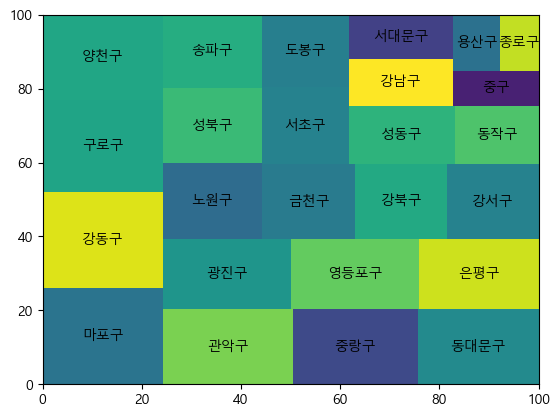

In [21]:
import squarify
squarify.plot(fin, label=fin.index)

### 영업상태가 폐업인 업장의 자치구별 분포도(업종:일반음식점)

In [5]:
data_fin = data[data.영업상태명=='폐업'] 
data_fin.head(1)

,번호,개방서비스명,개방서비스아이디,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태구분코드,영업상태명,상세영업상태코드,...,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지,Unnamed: 47
124208,124209,일반음식점,07_24_04_P,3220000,3220000-101-2020-00852,20200803,NaN,3,폐업,2,...,0.0,NaN,0.0,0,N,13.81,NaN,NaN,NaN,NaN


In [6]:
set(data_fin.영업상태명)

{'폐업'}

In [7]:
res = data_fin.소재지전체주소.str.split()
res

124208                    [서울특별시, 강남구, 삼성동, 157-18]
124209                       [서울특별시, 강남구, 논현동, 8-9]
124210                    [서울특별시, 광진구, 중곡동, 118-34]
124211         [서울특별시, 광진구, 구의동, 591-22, 강변리버빌101호]
124212             [서울특별시, 강남구, 압구정동, 429, 현대백화점본점]
                            ...                    
472910                    [서울특별시, 강남구, 역삼동, 799-18]
472911               [서울특별시, 강남구, 역삼동, 668-9, 해석빌딩]
472912                [서울특별시, 강남구, 논현동, 108, 논현웰스톤]
472913    [서울특별시, 강서구, 마곡동, 798-6, 류마타워Ⅱ, 3층, 310호]
472914                    [서울특별시, 마포구, 망원동, 435-34]
Name: 소재지전체주소, Length: 348707, dtype: object

In [8]:
res[472914][1]
res.index

Index([124208, 124209, 124210, 124211, 124212, 124213, 124214, 124215, 124216,
       124217,
       ...
       472905, 472906, 472907, 472908, 472909, 472910, 472911, 472912, 472913,
       472914],
      dtype='int64', length=348707)

In [9]:
fin_t = []
for idx in res.index :
    try :
        a=res[idx][1]
        fin_t.append(a)
    except : 
        pass

In [11]:
# fin_t

In [12]:
fin_s = pd.Series(fin_t) 
# 시리즈에 포함된 값들에 대해서 분류한후 개수를 세기 : pd(시리즈/df).value_counts()
fin_s.value_counts()
# 분류된 값의 개수를 센 후 내림차순으로 정렬된 결과를 반환

강남구     31816
송파구     19763
서초구     18940
영등포구    17467
강동구     17006
마포구     16997
동대문구    15648
관악구     15599
강서구     14219
구로구     13624
중구      13480
양천구     12947
서대문구    12535
성북구     12288
중랑구     12236
강북구     11914
은평구     11855
광진구     11792
종로구     11587
노원구     10731
동작구      9868
금천구      9311
용산구      9186
성동구      9099
도봉구      8640
성남시         2
고양시         2
제주시         1
수영구         1
Name: count, dtype: int64

In [13]:
fin_s.head(2)

0    강남구
1    강남구
dtype: object

In [14]:
tmp = []
for s in fin_s :
    tmp.append(s not in ['성남시','고양시','제주시','수영구'])
fin = fin_s[tmp].value_counts()

In [15]:
fin

강남구     31816
송파구     19763
서초구     18940
영등포구    17467
강동구     17006
마포구     16997
동대문구    15648
관악구     15599
강서구     14219
구로구     13624
중구      13480
양천구     12947
서대문구    12535
성북구     12288
중랑구     12236
강북구     11914
은평구     11855
광진구     11792
종로구     11587
노원구     10731
동작구      9868
금천구      9311
용산구      9186
성동구      9099
도봉구      8640
Name: count, dtype: int64

<Axes: >

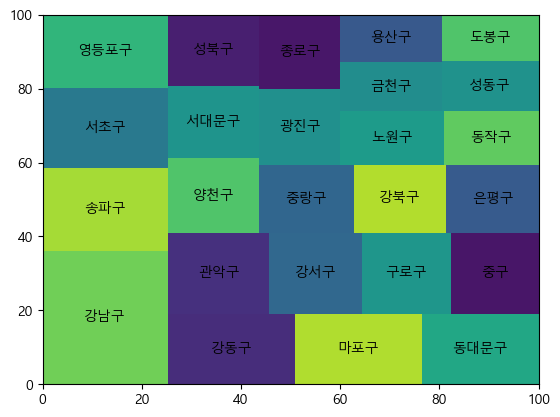

In [16]:
# 트리맵
import squarify
squarify.plot(fin, label=fin.index)

### Forium 패키지
- 지도 시각화 도구
- pip install folium
- 지도 생성 방법
    - Map()메서드에 중심 좌표값을 지정해서 간단하게 생상 가능
        - location 파라미터 : 중심 좌표값(위경도)으로 지도를 생성
        - zoom_start : 지도 확대 정도(절대수치)
        - tiles : 지도 스타일 변경
            - Stamen Toner, Stamen Terrain
        - 크롬에서는 출력이 가능하고, 브라우저별로 상이할 수 있음

In [ ]:
!pip install folium

In [17]:
import folium

In [19]:
map_tmp = folium.Map(location=[45.5236,-122.6750], zoom_start=13,
                    tiles='Stamen Toner')
map_tmp

- 마커설정(popup 설정도 가능)
    - 마커(특정 위치를 표시하는 표식)
    - popup(마커 클릭시 나타나는 정보) : os에 따라 지원 안되는 경우도 있음
1. 마커 생성
    - folium.Marker() : 위경도 리스트, popup 문자
    - 표시하고자하는 위치 수 만큼 생성해야 함
2. 생성된 마커를 지도에 부착
    - folium.Marker().add_to(지도객체변수)

In [27]:
map_1 = folium.Map(location=[45.372,-121.6972], 
                    tiles='Stamen Terrain')
folium.Marker([45.3288,-121.6625],popup='Hood 산',
             icon=folium.Icon(icon='cloud')).add_to(map_1)
folium.Marker([45.3211,-121.7113],popup='Lodge',
             icon=folium.Icon(color='red')).add_to(map_1)
folium.Marker([45.3300,-121.6823],popup='other',
             icon=folium.Icon(color='blue', icon='info-sign')).add_to(map_1)
map_1

### 단계 구분도 그리기
1. 맵객체 생성
2. 맵객체.choropleth()
    - geo_data : 지도파일의 경로와 파일명, 지도정보 변수명
    - data : 지도에 표현되어야 할 값변수
    - columns : [key로 사용할 data, 값 데이터]
    - key_on : 지도 경계파일인 json에서 사용할 key 값 , Data는 표준형식으로 만들어져야 함
3. 지도에 추가 : folium.LayoutControl().add_to(지도객체)

In [28]:
## 서울시 지도 생성
## 서울시 중심 위경도[37.5502,126.982]
map = folium.Map(location=[37.5502,126.982],
                zoom_start=11,
                tiles='Stamen Toner')
map

In [30]:
import json
geo_path = './data/02. skorea_municipalities_geo_simple.json'
geo_str = json.load(open(geo_path, encoding='utf-8'))
geo_str

{'type': 'FeatureCollection',
 'features': [{'type': 'Feature',
   'id': '강동구',
   'properties': {'code': '11250',
    'name': '강동구',
    'name_eng': 'Gangdong-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.11519584981606, 37.557533180704915],
      [127.16683184366129, 37.57672487388627],
      [127.18408792330152, 37.55814280369575],
      [127.16530984307447, 37.54221851258693],
      [127.14672806823502, 37.51415680680291],
      [127.12123165719615, 37.52528270089],
      [127.1116764203608, 37.540669955324965],
      [127.11519584981606, 37.557533180704915]]]}},
  {'type': 'Feature',
   'id': '송파구',
   'properties': {'code': '11240',
    'name': '송파구',
    'name_eng': 'Songpa-gu',
    'base_year': '2013'},
   'geometry': {'type': 'Polygon',
    'coordinates': [[[127.0690698130372, 37.522279423505026],
      [127.10087519791962, 37.524841220167055],
      [127.1116764203608, 37.540669955324965],
      [127.12123165719615, 37.52528270089

In [32]:
map.choropleth(geo_data=geo_str,
                     data=fin,
                     column=[fin.index, fin],
                     key_on='feature.id',
                     fill_color='PuRd',
                     legend_name='폐업현황')
folium.LayerControl().add_to(map)
map

C:\Users\USER\anaconda3\Lib\site-packages\folium\folium.py:465: FutureWarning: The choropleth  method has been deprecated. Instead use the new Choropleth class, which has the same arguments. See the example notebook 'GeoJSON_and_choropleth' for how to do this.
  warnings.warn(
